In [91]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import math

In [92]:
soccer = pd.read_csv('../output/csvs/soccer_generalized_cscores.csv')
soccer

,League,Season,Team,Sequence,n,n1,n2,k,k1,k2,c1,c2,c3,n1*,c1*,n2*,c2*
0,Bundesliga,2000,Bayern Munich,"[1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1, ...",28,14,14,19,9,10,1.414208,1.521762,1.233046,10,2.449470,10.0,3.944894
1,Bundesliga,2000,Bochum,"[1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, ...",28,14,14,7,5,2,3.557103,10.502532,4.975124,5,4.213992,5.0,12.959781
2,Bundesliga,2000,Cottbus,"[0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, ...",31,16,15,12,6,6,1.540103,1.796042,1.443001,13,1.633396,13.0,2.039216
3,Bundesliga,2000,Dortmund,"[1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, ...",24,12,12,16,7,9,1.221184,1.239523,1.118568,8,1.880482,5.0,2.768998
4,Bundesliga,2000,Ein Frankfurt,"[1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, ...",29,15,14,10,6,4,2.278359,3.863890,2.433090,10,3.663872,10.0,8.551127
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1433,La_Liga,2024,Sociedad,"[0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, ...",31,16,15,13,8,5,2.899686,5.758226,3.367003,6,4.892563,6.0,12.309017
1434,La_Liga,2024,Valencia,"[0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, ...",25,13,12,11,3,8,1.031319,1.014335,1.003009,2,3.188776,2.0,10.458316
1435,La_Liga,2024,Valladolid,"[1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, ...",34,17,17,4,4,0,8.396151,60.167004,19.872814,17,8.396151,17.0,60.167004
1436,La_Liga,2024,Vallecano,"[1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, ...",25,13,12,13,7,6,1.793021,2.359879,1.686341,10,3.041173,10.0,6.119959


In [93]:
us_leagues = pd.read_csv('../output/csvs/us_generalized_cscores.csv')
us_leagues

,League,Season,Team,Sequence,n,n1,n2,k,k1,k2,c1,c2,c3,n1*,c1*,n2*,c2*
0,NBA,2015,Orlando Magic,"[0, 0, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, ...",82,41,41,35,20,15,3.764011,7.567749,5.617978,41,3.764011,41,7.567749
1,NBA,2015,Houston Rockets,"[0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, ...",82,41,41,41,21,20,2.000000,2.423658,2.057613,35,2.717839,35,3.976260
2,NBA,2015,Oklahoma City Thunder,"[1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 1, ...",82,41,41,55,29,26,2.749747,4.159434,3.300330,8,11.926959,8,32.797102
3,NBA,2015,Sacramento Kings,"[0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, ...",82,41,41,33,18,15,2.639310,4.005520,3.105590,39,4.190481,39,8.918303
4,NBA,2015,Utah Jazz,"[0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, ...",82,41,41,40,18,22,1.277825,1.232172,1.136364,5,4.923305,2,12.320543
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4318,NBA,1982,Indiana Pacers,"[1, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, ...",82,41,41,20,13,7,5.464184,16.280440,9.009009,37,12.046809,37,53.259359
4319,NBA,1982,Washington Bullets,"[0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, ...",82,41,41,42,18,24,1.158671,1.101917,1.064963,3,2.075934,1,6.610688
4320,NBA,1982,Dallas Mavericks,"[1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, ...",82,41,41,38,19,19,1.774389,2.000000,1.808318,11,18.279912,11,45.312997
4321,NBA,1982,Denver Nuggets,"[0, 1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, ...",82,41,41,45,19,26,1.115894,1.064008,1.047120,15,1.812723,15,2.236664


In [94]:
soccer['n2*'].value_counts().reset_index()

,n2*,count
0,1.0,239
1,2.0,170
2,3.0,122
3,6.0,94
4,7.0,94
5,5.0,91
6,4.0,90
7,8.0,87
8,9.0,79
9,11.0,79


In [95]:
soccer['normalized_n2*'] = soccer['n2*']/soccer['n']
soccer

,League,Season,Team,Sequence,n,n1,n2,k,k1,k2,c1,c2,c3,n1*,c1*,n2*,c2*,normalized_n2*
0,Bundesliga,2000,Bayern Munich,"[1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1, ...",28,14,14,19,9,10,1.414208,1.521762,1.233046,10,2.449470,10.0,3.944894,0.357143
1,Bundesliga,2000,Bochum,"[1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, ...",28,14,14,7,5,2,3.557103,10.502532,4.975124,5,4.213992,5.0,12.959781,0.178571
2,Bundesliga,2000,Cottbus,"[0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, ...",31,16,15,12,6,6,1.540103,1.796042,1.443001,13,1.633396,13.0,2.039216,0.419355
3,Bundesliga,2000,Dortmund,"[1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, ...",24,12,12,16,7,9,1.221184,1.239523,1.118568,8,1.880482,5.0,2.768998,0.208333
4,Bundesliga,2000,Ein Frankfurt,"[1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, ...",29,15,14,10,6,4,2.278359,3.863890,2.433090,10,3.663872,10.0,8.551127,0.344828
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1433,La_Liga,2024,Sociedad,"[0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, ...",31,16,15,13,8,5,2.899686,5.758226,3.367003,6,4.892563,6.0,12.309017,0.193548
1434,La_Liga,2024,Valencia,"[0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, ...",25,13,12,11,3,8,1.031319,1.014335,1.003009,2,3.188776,2.0,10.458316,0.080000
1435,La_Liga,2024,Valladolid,"[1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, ...",34,17,17,4,4,0,8.396151,60.167004,19.872814,17,8.396151,17.0,60.167004,0.500000
1436,La_Liga,2024,Vallecano,"[1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, ...",25,13,12,13,7,6,1.793021,2.359879,1.686341,10,3.041173,10.0,6.119959,0.400000


In [96]:
soccer['normalized_n2*'].describe().reset_index()

,index,normalized_n2*
0,count,1433.000000
1,mean,0.229465
2,std,0.155140
3,min,0.027778
4,25%,0.080000
5,50%,0.206897
6,75%,0.370370
7,max,0.500000


# Soccer Analysis

## N2* Summary Statistics

### Overall Across All Leagues

In [97]:
soccer_n2_counts = soccer['n2*'].value_counts().reset_index()
soccer_n2_counts

,n2*,count
0,1.0,239
1,2.0,170
2,3.0,122
3,6.0,94
4,7.0,94
5,5.0,91
6,4.0,90
7,8.0,87
8,9.0,79
9,11.0,79


In [98]:
soccer_n2_summary = soccer['n2*'].describe().reset_index()
soccer_n2_summary

,index,n2*
0,count,1433.000000
1,mean,6.177251
2,std,4.291652
3,min,1.000000
4,25%,2.000000
5,50%,6.000000
6,75%,10.000000
7,max,17.000000


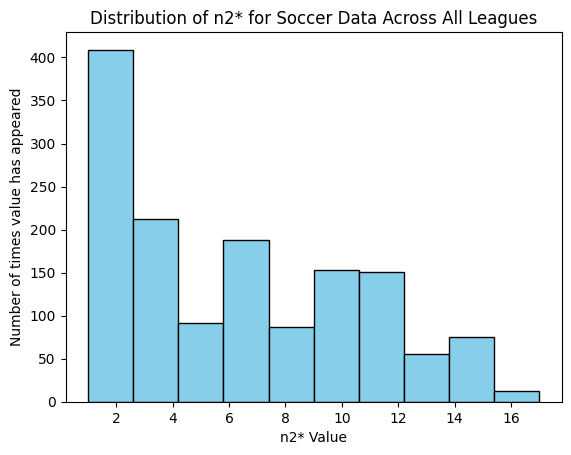

In [99]:
plt.hist(soccer['n2*'],color='skyblue', edgecolor='black')
plt.ylabel('Number of times value has appeared')
plt.xlabel('n2* Value')
plt.title('Distribution of n2* for Soccer Data Across All Leagues')
plt.show()

#### Premier League

In [100]:
pl_soccer = soccer[soccer['League']=='Premier_League']
pl_soccer

,League,Season,Team,Sequence,n,n1,n2,k,k1,k2,c1,c2,c3,n1*,c1*,n2*,c2*,normalized_n2*
451,Premier_League,2000,Arsenal,"[0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, ...",28,14,14,20,10,10,1.666866,2.000000,1.555210,1,3.500000,1.0,18.628137,0.035714
452,Premier_League,2000,Aston Villa,"[0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, ...",23,12,11,13,7,6,1.778085,2.339846,1.689189,1,2.300000,1.0,8.206977,0.043478
453,Premier_League,2000,Bradford,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, ...",27,14,13,5,2,3,1.263532,1.385821,1.193317,3,1.848516,3.0,5.247517,0.111111
454,Premier_League,2000,Charlton,"[1, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, ...",28,14,14,14,6,8,1.268995,1.290066,1.128668,2,4.000000,2.0,14.063388,0.071429
455,Premier_League,2000,Chelsea,"[1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, ...",28,14,14,17,7,10,1.157062,1.140055,1.067236,4,1.951518,4.0,3.146842,0.142857
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
950,Premier_League,2024,Nottm Forest,"[1, 1, 0, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1]",13,7,6,9,5,4,1.677028,2.345006,1.488095,6,1.677028,6.0,2.345006,0.461538
951,Premier_League,2024,Southampton,"[0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, ...",32,16,16,2,1,1,1.358905,2.000000,1.305483,11,2.033836,11.0,6.885488,0.343750
952,Premier_League,2024,Tottenham,"[1, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, ...",33,17,16,11,7,4,2.948780,6.162692,3.649635,6,11.390625,6.0,36.028832,0.181818
953,Premier_League,2024,West Ham,"[0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0, ...",28,14,14,11,6,5,1.968326,2.862086,1.984127,7,2.295970,7.0,3.978388,0.250000


In [101]:
pl_n2_counts = pl_soccer['n2*'].value_counts().reset_index()
pl_n2_counts

,n2*,count
0,1.0,83
1,2.0,58
2,3.0,49
3,7.0,37
4,5.0,32
5,6.0,32
6,10.0,29
7,8.0,29
8,4.0,28
9,9.0,26


In [102]:
pl_n2_summary = pl_soccer['n2*'].describe().reset_index()
pl_n2_summary

,index,n2*
0,count,502.000000
1,mean,6.179283
2,std,4.332458
3,min,1.000000
4,25%,2.000000
5,50%,6.000000
6,75%,10.000000
7,max,17.000000


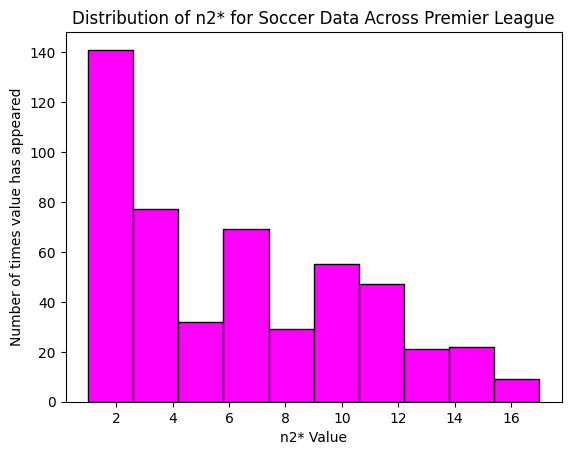

In [103]:
plt.hist(pl_soccer['n2*'],color='magenta', edgecolor='black')
plt.ylabel('Number of times value has appeared')
plt.xlabel('n2* Value')
plt.title('Distribution of n2* for Soccer Data Across Premier League')
plt.show()

### La Liga

In [104]:
la_liga_soccer = soccer[soccer['League']=='La_Liga']
la_liga_soccer

,League,Season,Team,Sequence,n,n1,n2,k,k1,k2,c1,c2,c3,n1*,c1*,n2*,c2*,normalized_n2*
955,La_Liga,2000,Alaves,"[1, 0, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, ...",31,16,15,14,7,7,1.541379,1.770633,1.420455,5,20.163404,5.0,74.880182,0.161290
956,La_Liga,2000,Ath Bilbao,"[0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, ...",28,14,14,11,7,4,3.355384,8.140033,4.484305,5,12.121198,5.0,42.382306,0.178571
957,La_Liga,2000,Barcelona,"[1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, ...",26,13,13,17,8,9,1.404774,1.515347,1.267427,9,2.621374,9.0,4.510932,0.346154
958,La_Liga,2000,Celta,"[1, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, ...",27,14,13,16,5,11,1.011167,1.004908,1.001001,6,1.285244,3.0,1.641785,0.111111
959,La_Liga,2000,Espanol,"[1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, ...",30,15,15,14,6,8,1.279884,1.302265,1.138952,5,4.311495,5.0,10.502532,0.166667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1433,La_Liga,2024,Sociedad,"[0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, ...",31,16,15,13,8,5,2.899686,5.758226,3.367003,6,4.892563,6.0,12.309017,0.193548
1434,La_Liga,2024,Valencia,"[0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, ...",25,13,12,11,3,8,1.031319,1.014335,1.003009,2,3.188776,2.0,10.458316,0.080000
1435,La_Liga,2024,Valladolid,"[1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, ...",34,17,17,4,4,0,8.396151,60.167004,19.872814,17,8.396151,17.0,60.167004,0.500000
1436,La_Liga,2024,Vallecano,"[1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, ...",25,13,12,13,7,6,1.793021,2.359879,1.686341,10,3.041173,10.0,6.119959,0.400000


In [105]:
la_liga_n2_counts = la_liga_soccer['n2*'].value_counts().reset_index()
la_liga_n2_counts

,n2*,count
0,1.0,80
1,2.0,60
2,3.0,41
3,6.0,34
4,8.0,33
5,4.0,29
6,5.0,28
7,12.0,28
8,11.0,27
9,9.0,25


In [106]:
la_liga_n2_summary = la_liga_soccer['n2*'].describe().reset_index()
la_liga_n2_summary

,index,n2*
0,count,481.000000
1,mean,6.305613
2,std,4.465160
3,min,1.000000
4,25%,2.000000
5,50%,6.000000
6,75%,10.000000
7,max,17.000000


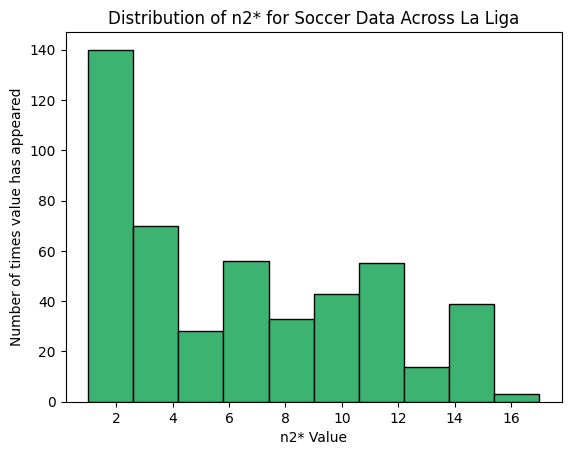

In [107]:
plt.hist(la_liga_soccer['n2*'],color='mediumseagreen', edgecolor='black')
plt.ylabel('Number of times value has appeared')
plt.xlabel('n2* Value')
plt.title('Distribution of n2* for Soccer Data Across La Liga')
plt.show()

### Bundesliga

In [108]:
bundesliga_soccer = soccer[soccer['League']=='Bundesliga']
bundesliga_soccer

,League,Season,Team,Sequence,n,n1,n2,k,k1,k2,c1,c2,c3,n1*,c1*,n2*,c2*,normalized_n2*
0,Bundesliga,2000,Bayern Munich,"[1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1, ...",28,14,14,19,9,10,1.414208,1.521762,1.233046,10,2.449470,10.0,3.944894,0.357143
1,Bundesliga,2000,Bochum,"[1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, ...",28,14,14,7,5,2,3.557103,10.502532,4.975124,5,4.213992,5.0,12.959781,0.178571
2,Bundesliga,2000,Cottbus,"[0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, ...",31,16,15,12,6,6,1.540103,1.796042,1.443001,13,1.633396,13.0,2.039216,0.419355
3,Bundesliga,2000,Dortmund,"[1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, ...",24,12,12,16,7,9,1.221184,1.239523,1.118568,8,1.880482,5.0,2.768998,0.208333
4,Bundesliga,2000,Ein Frankfurt,"[1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, ...",29,15,14,10,6,4,2.278359,3.863890,2.433090,10,3.663872,10.0,8.551127,0.344828
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
446,Bundesliga,2024,St Pauli,"[0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, ...",26,13,13,8,4,4,1.584677,2.000000,1.497006,9,2.260079,2.0,6.126672,0.076923
447,Bundesliga,2024,Stuttgart,"[0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0, ...",26,13,13,14,9,5,4.952094,17.303747,8.415383,13,4.952094,13.0,17.303747,0.500000
448,Bundesliga,2024,Union Berlin,"[1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, ...",23,12,11,10,4,6,1.174159,1.180163,1.090513,8,1.302236,2.0,1.732531,0.086957
449,Bundesliga,2024,Werder Bremen,"[1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1, 0, ...",25,13,12,14,7,7,1.491683,1.696854,1.345895,11,1.734933,11.0,2.230477,0.440000


In [109]:
bundesliga_n2_counts = bundesliga_soccer['n2*'].value_counts().reset_index()
bundesliga_n2_counts

,n2*,count
0,1.0,76
1,2.0,52
2,7.0,35
3,4.0,33
4,3.0,32
5,5.0,31
6,9.0,28
7,6.0,28
8,11.0,28
9,10.0,27


In [110]:
bundesliga_n2_summary = bundesliga_soccer['n2*'].describe().reset_index()
bundesliga_n2_summary

,index,n2*
0,count,450.000000
1,mean,6.037778
2,std,4.055395
3,min,1.000000
4,25%,2.000000
5,50%,6.000000
6,75%,9.000000
7,max,15.000000


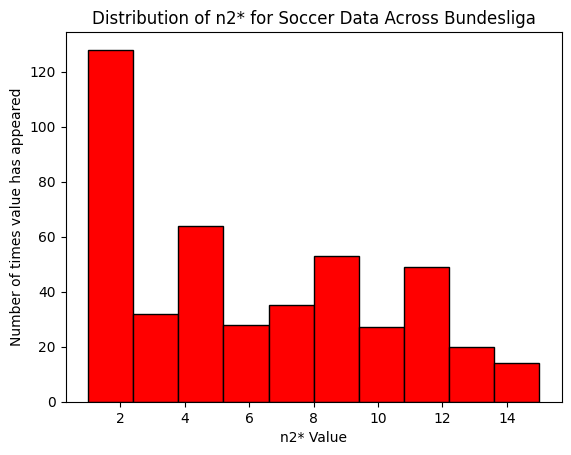

In [111]:
plt.hist(bundesliga_soccer['n2*'],color='red', edgecolor='black')
plt.ylabel('Number of times value has appeared')
plt.xlabel('n2* Value')
plt.title('Distribution of n2* for Soccer Data Across Bundesliga')
plt.show()

## Soccer normalized n2* summary statistics

### Overall Leagues

In [112]:
normalized_soccer_n2_counts = soccer['normalized_n2*'].value_counts().reset_index()
normalized_soccer_n2_counts

,normalized_n2*,count
0,0.500000,59
1,0.035714,38
2,0.333333,26
3,0.034483,26
4,0.037037,25
...,...,...
178,0.264706,1
179,0.187500,1
180,0.055556,1
181,0.194444,1


In [113]:
normalized_soccer_n2_summary = soccer['normalized_n2*'].describe().reset_index()
normalized_soccer_n2_summary

,index,normalized_n2*
0,count,1433.000000
1,mean,0.229465
2,std,0.155140
3,min,0.027778
4,25%,0.080000
5,50%,0.206897
6,75%,0.370370
7,max,0.500000


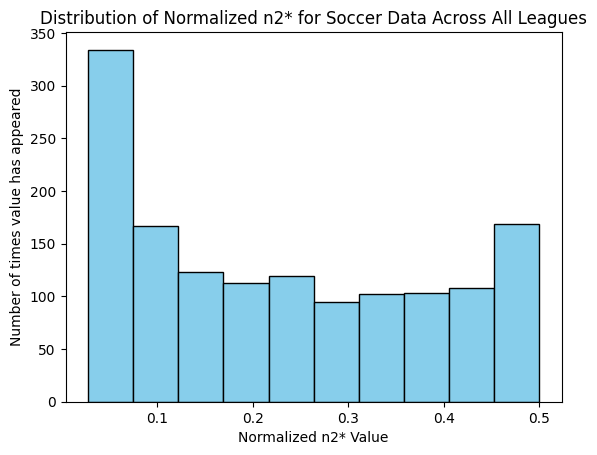

In [114]:
plt.hist(soccer['normalized_n2*'],color='skyblue', edgecolor='black')
plt.ylabel('Number of times value has appeared')
plt.xlabel('Normalized n2* Value')
plt.title('Distribution of Normalized n2* for Soccer Data Across All Leagues')
plt.show()

### Premier League

In [115]:
pl_normalized_n2_counts = pl_soccer['normalized_n2*'].value_counts().reset_index()
pl_normalized_n2_counts

,normalized_n2*,count
0,0.500000,15
1,0.035714,12
2,0.034483,12
3,0.033333,11
4,0.032258,11
...,...,...
145,0.342857,1
146,0.242424,1
147,0.458333,1
148,0.212121,1


In [116]:
pl_normalized_n2_summary = pl_soccer['normalized_n2*'].describe().reset_index()
pl_normalized_n2_summary

,index,normalized_n2*
0,count,502.000000
1,mean,0.221664
2,std,0.151867
3,min,0.027778
4,25%,0.074074
5,50%,0.200000
6,75%,0.347826
7,max,0.500000


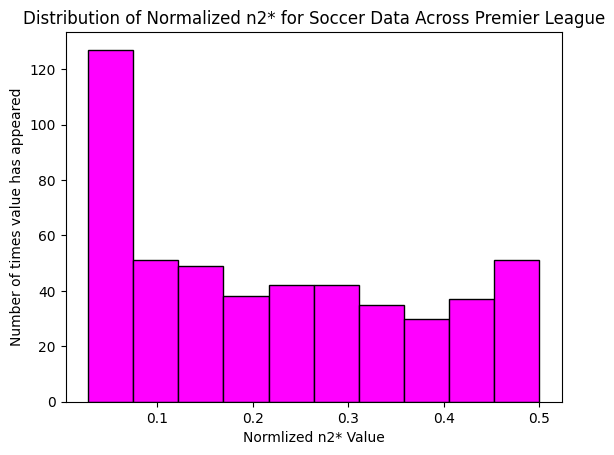

In [117]:
plt.hist(pl_soccer['normalized_n2*'],color='magenta', edgecolor='black')
plt.ylabel('Number of times value has appeared')
plt.xlabel('Normlized n2* Value')
plt.title('Distribution of Normalized n2* for Soccer Data Across Premier League')
plt.show()

### La Liga

In [118]:
la_liga_normalized_n2_counts = la_liga_soccer['normalized_n2*'].value_counts().reset_index()
la_liga_normalized_n2_counts

,normalized_n2*,count
0,0.500000,19
1,0.035714,13
2,0.100000,11
3,0.333333,11
4,0.034483,11
...,...,...
138,0.030303,1
139,0.108108,1
140,0.117647,1
141,0.423077,1


In [119]:
la_liga_normalized_n2_summary = la_liga_soccer['normalized_n2*'].describe().reset_index()
la_liga_normalized_n2_summary

,index,normalized_n2*
0,count,481.000000
1,mean,0.227346
2,std,0.157350
3,min,0.027778
4,25%,0.076923
5,50%,0.200000
6,75%,0.375000
7,max,0.500000


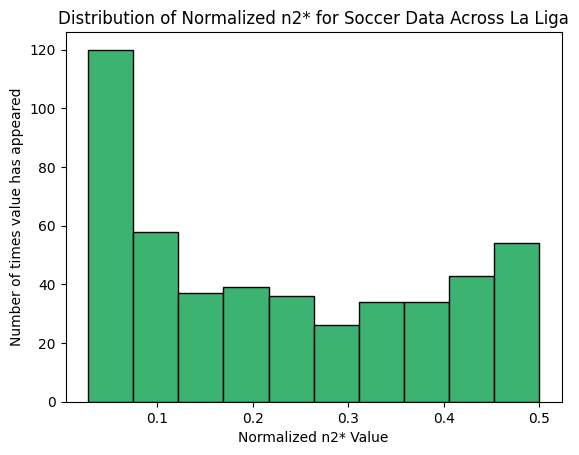

In [120]:
plt.hist(la_liga_soccer['normalized_n2*'],color='mediumseagreen', edgecolor='black')
plt.ylabel('Number of times value has appeared')
plt.xlabel('Normalized n2* Value')
plt.title('Distribution of Normalized n2* for Soccer Data Across La Liga')
plt.show()

### Bundesliga

In [121]:
bundesliga_normalized_n2_counts = bundesliga_soccer['normalized_n2*'].value_counts().reset_index()
bundesliga_normalized_n2_counts

,normalized_n2*,count
0,0.500000,25
1,0.250000,15
2,0.035714,13
3,0.333333,12
4,0.083333,12
...,...,...
123,0.129032,1
124,0.363636,1
125,0.142857,1
126,0.050000,1


In [122]:
bundesliga_normalized_n2_summary = bundesliga_soccer['normalized_n2*'].describe().reset_index()
bundesliga_normalized_n2_summary

,index,normalized_n2*
0,count,450.000000
1,mean,0.240433
2,std,0.156094
3,min,0.032258
4,25%,0.083333
5,50%,0.230769
6,75%,0.375000
7,max,0.500000


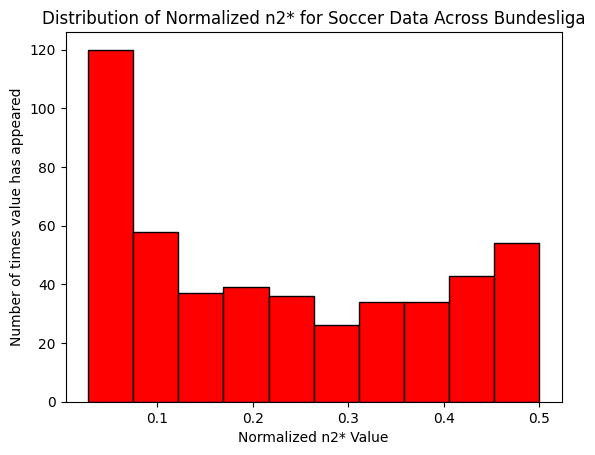

In [123]:
plt.hist(la_liga_soccer['normalized_n2*'],color='red', edgecolor='black')
plt.ylabel('Number of times value has appeared')
plt.xlabel('Normalized n2* Value')
plt.title('Distribution of Normalized n2* for Soccer Data Across Bundesliga')
plt.show()

# US Leagues 

In [124]:
us_leagues['League'].unique()

array(['NBA', 'MLB'], dtype=object)

In [125]:
us_leagues['normalized_n2*'] = us_leagues['n2*']/us_leagues['n']
us_leagues

,League,Season,Team,Sequence,n,n1,n2,k,k1,k2,c1,c2,c3,n1*,c1*,n2*,c2*,normalized_n2*
0,NBA,2015,Orlando Magic,"[0, 0, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, ...",82,41,41,35,20,15,3.764011,7.567749,5.617978,41,3.764011,41,7.567749,0.500000
1,NBA,2015,Houston Rockets,"[0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, ...",82,41,41,41,21,20,2.000000,2.423658,2.057613,35,2.717839,35,3.976260,0.426829
2,NBA,2015,Oklahoma City Thunder,"[1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 1, ...",82,41,41,55,29,26,2.749747,4.159434,3.300330,8,11.926959,8,32.797102,0.097561
3,NBA,2015,Sacramento Kings,"[0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, ...",82,41,41,33,18,15,2.639310,4.005520,3.105590,39,4.190481,39,8.918303,0.475610
4,NBA,2015,Utah Jazz,"[0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, ...",82,41,41,40,18,22,1.277825,1.232172,1.136364,5,4.923305,2,12.320543,0.024390
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4318,NBA,1982,Indiana Pacers,"[1, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, ...",82,41,41,20,13,7,5.464184,16.280440,9.009009,37,12.046809,37,53.259359,0.451220
4319,NBA,1982,Washington Bullets,"[0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, ...",82,41,41,42,18,24,1.158671,1.101917,1.064963,3,2.075934,1,6.610688,0.012195
4320,NBA,1982,Dallas Mavericks,"[1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, ...",82,41,41,38,19,19,1.774389,2.000000,1.808318,11,18.279912,11,45.312997,0.134146
4321,NBA,1982,Denver Nuggets,"[0, 1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, ...",82,41,41,45,19,26,1.115894,1.064008,1.047120,15,1.812723,15,2.236664,0.182927


## N2* Analysis

### Across All Leagues

In [126]:
us_leagues_n2_counts = us_leagues['n2*'].value_counts().reset_index()
us_leagues_n2_counts

,n2*,count
0,1,473
1,2,342
2,3,247
3,4,208
4,5,165
...,...,...
76,62,11
77,51,10
78,64,8
79,60,8


In [127]:
us_leagues_n2_summary = us_leagues['n2*'].describe().reset_index()
us_leagues_n2_summary

,index,n2*
0,count,4323.000000
1,mean,21.942401
2,std,22.439876
3,min,1.000000
4,25%,4.000000
5,50%,13.000000
6,75%,35.000000
7,max,81.000000


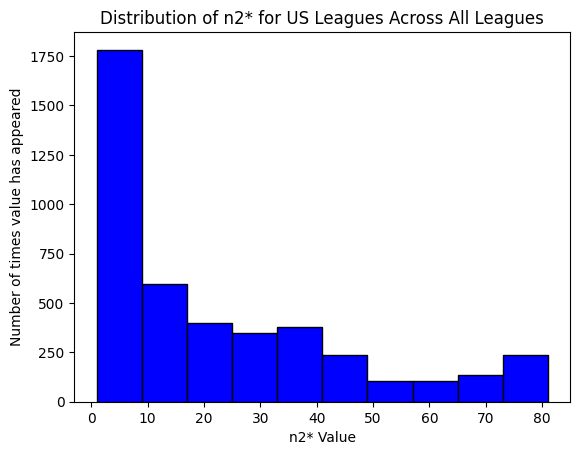

In [128]:
plt.hist(us_leagues['n2*'],color='blue', edgecolor='black')
plt.ylabel('Number of times value has appeared')
plt.xlabel('n2* Value')
plt.title('Distribution of n2* for US Leagues Across All Leagues')
plt.show()

### NBA

In [129]:
us_leagues.columns

Index(['League', 'Season', 'Team', 'Sequence', 'n', 'n1', 'n2', 'k', 'k1',
       'k2', 'c1', 'c2', 'c3', 'n1*', 'c1*', 'n2*', 'c2*', 'normalized_n2*'],
      dtype='object')

In [130]:
nba = us_leagues.loc[us_leagues['League'] == 'NBA']
nba['n2*'].value_counts().reset_index()

,n2*,count
0,1,240
1,2,167
2,3,132
3,4,103
4,41,98
5,5,85
6,6,70
7,7,60
8,8,53
9,9,47


In [131]:
nba_n2_summary = nba['n2'].describe().reset_index()
nba_n2_summary

,index,n2
0,count,2017.000000
1,mean,40.554289
2,std,2.773377
3,min,25.000000
4,25%,41.000000
5,50%,41.000000
6,75%,41.000000
7,max,48.000000


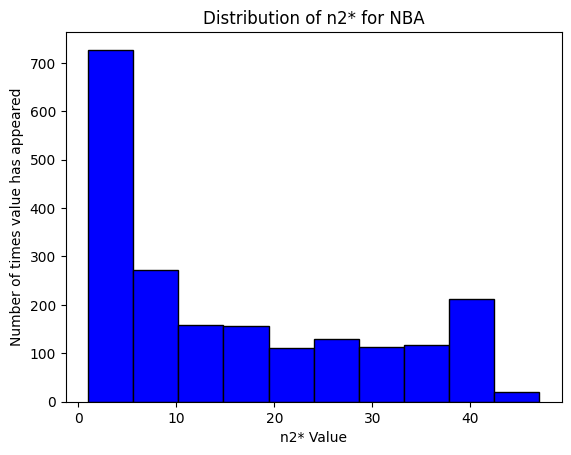

In [132]:
plt.hist(nba['n2*'],color='blue', edgecolor='black')
plt.ylabel('Number of times value has appeared')
plt.xlabel('n2* Value')
plt.title('Distribution of n2* for NBA')
plt.show()



### MLB

In [133]:
mlb = us_leagues.loc[us_leagues['League'] == 'MLB']
mlb['n2*'].value_counts().reset_index()

,n2*,count
0,1,233
1,2,175
2,3,115
3,4,105
4,5,80
...,...,...
76,51,10
77,43,8
78,64,8
79,60,8


In [134]:
mlb_n2_summary = mlb['n2'].describe().reset_index()
mlb_n2_summary

,index,n2
0,count,2306.000000
1,mean,78.390286
2,std,7.017386
3,min,29.000000
4,25%,77.000000
5,50%,81.000000
6,75%,81.000000
7,max,82.000000


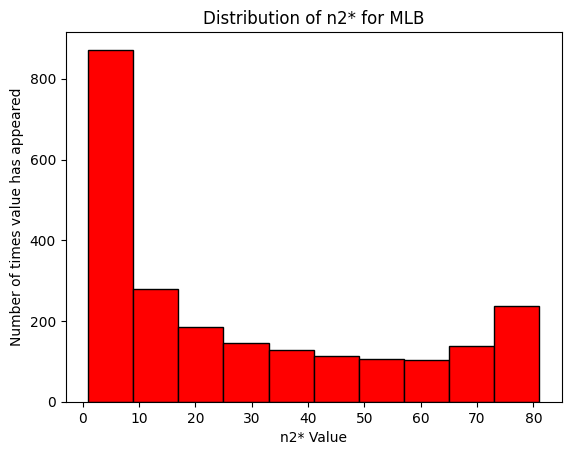

In [135]:
plt.hist(mlb['n2*'],color='red', edgecolor='black')
plt.ylabel('Number of times value has appeared')
plt.xlabel('n2* Value')
plt.title('Distribution of n2* for MLB')
plt.show()

## Normalized N2* Analysis

### Across All Leagues

In [136]:
us_leagues['normalized_n2*'].value_counts().reset_index()

,normalized_n2*,count
0,0.500000,176
1,0.012195,175
2,0.006173,146
3,0.024390,126
4,0.012346,102
...,...,...
667,0.190789,1
668,0.105263,1
669,0.138158,1
670,0.118421,1


In [137]:
us_leagues['normalized_n2*'].describe().reset_index()

,index,normalized_n2*
0,count,4323.000000
1,mean,0.183212
2,std,0.168713
3,min,0.006135
4,25%,0.031056
5,50%,0.121951
6,75%,0.329268
7,max,0.500000


<function matplotlib.pyplot.show(close=None, block=None)>

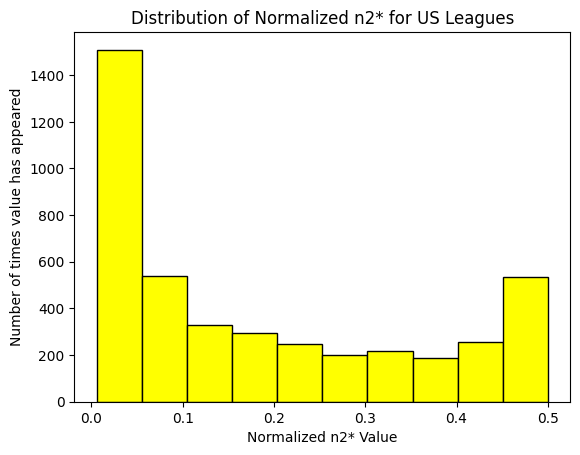

In [143]:
plt.hist(us_leagues['normalized_n2*'],color='yellow', edgecolor='black')
plt.ylabel('Number of times value has appeared')
plt.xlabel('Normalized n2* Value')
plt.title('Distribution of Normalized n2* for US Leagues')
plt.show

### NBA

In [140]:
nba['normalized_n2*'].value_counts().reset_index()

,normalized_n2*,count
0,0.012195,175
1,0.024390,126
2,0.500000,116
3,0.036585,89
4,0.048780,74
...,...,...
232,0.472222,1
233,0.136364,1
234,0.015385,1
235,0.126761,1


In [141]:
nba['normalized_n2*'].describe().reset_index()

,index,normalized_n2*
0,count,2017.000000
1,mean,0.191826
2,std,0.168418
3,min,0.010638
4,25%,0.036585
5,50%,0.134146
6,75%,0.341463
7,max,0.500000


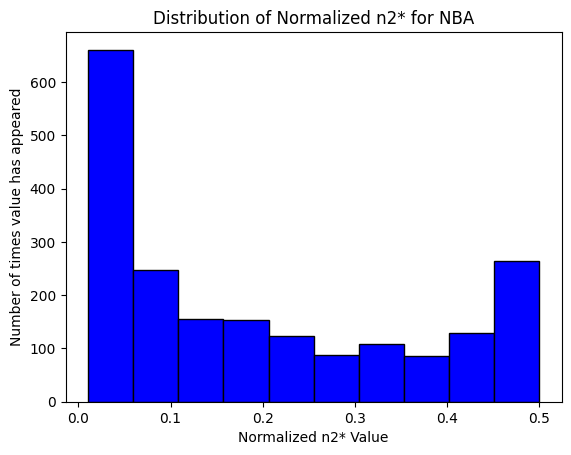

In [147]:
plt.hist(nba['normalized_n2*'],color='blue', edgecolor='black')
plt.ylabel('Number of times value has appeared')
plt.xlabel('Normalized n2* Value')
plt.title('Distribution of Normalized n2* for NBA')
plt.show()

### MLB

In [145]:
mlb['normalized_n2*'].value_counts().reset_index()

,normalized_n2*,count
0,0.006173,146
1,0.012346,100
2,0.018519,74
3,0.500000,60
4,0.024691,60
...,...,...
476,0.493056,1
477,0.229167,1
478,0.354037,1
479,0.136646,1


In [146]:
mlb['normalized_n2*'].describe().reset_index()

,index,normalized_n2*
0,count,2306.000000
1,mean,0.175678
2,std,0.168646
3,min,0.006135
4,25%,0.024730
5,50%,0.104938
6,75%,0.320988
7,max,0.500000


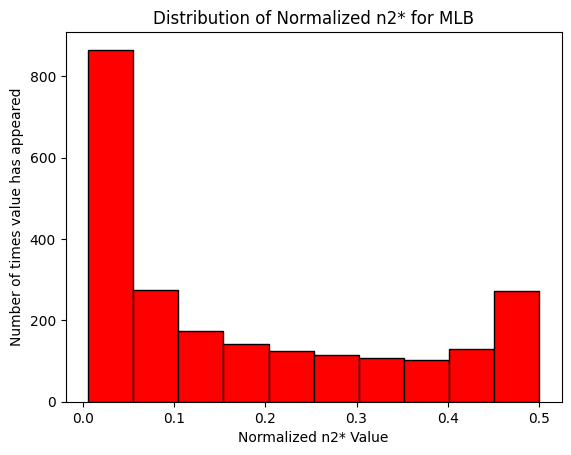

In [149]:
plt.hist(mlb['normalized_n2*'],color='red', edgecolor='black')
plt.ylabel('Number of times value has appeared')
plt.xlabel('Normalized n2* Value')
plt.title('Distribution of Normalized n2* for MLB')
plt.show()

In [150]:
combined = pd.concat([soccer, us_leagues], ignore_index=True)

In [152]:
combined['normalized_n2*'].value_counts().reset_index()

,normalized_n2*,count
0,0.500000,235
1,0.012195,175
2,0.006173,146
3,0.024390,126
4,0.012346,102
...,...,...
748,0.150327,1
749,0.146497,1
750,0.012739,1
751,0.366013,1


In [153]:
combined['normalized_n2*'].describe().reset_index()

,index,normalized_n2*
0,count,5756.000000
1,mean,0.194727
2,std,0.166629
3,min,0.006135
4,25%,0.040000
5,50%,0.146018
6,75%,0.341463
7,max,0.500000


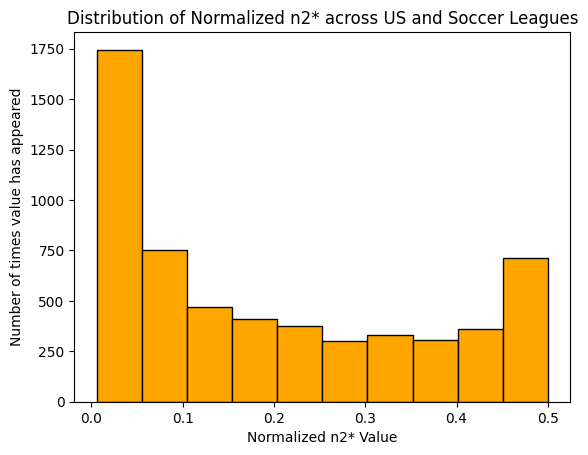

In [154]:
plt.hist(combined['normalized_n2*'],color='orange', edgecolor='black')
plt.ylabel('Number of times value has appeared')
plt.xlabel('Normalized n2* Value')
plt.title('Distribution of Normalized n2* across US and Soccer Leagues')
plt.show()